# Healthcare: Medical Insurance Cost Prediction

# Exploratory Data Analysis (EDA) and Visualization

## Objectives
-	Understand data distribution
-	Identify relationships between variables
-	Detect outliers
-	Discover key drivers of insurance charges

## 1. Import Required Libraries

In [110]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## 2. import Dataset

In [111]:
df = pd.read_csv(r"C:\Users\Divine\Downloads\insurance.csv")

In [112]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [114]:
df.shape

(1338, 7)

In [115]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Duplicate Records

In [116]:
df.duplicated().sum()

np.int64(1)

In [117]:
#remove duplicate records if any exist

df = df.drop_duplicates()

In [118]:
df.duplicated().sum()

np.int64(0)

## 3. Understand the Dataset

| Variable | Description                              |
| -------- | ---------------------------------------- |
| age      | Age of beneficiary                       |
| sex      | Male/Female                              |
| bmi      | Body Mass Index                          |
| children | Number of dependents                     |
| smoker   | Smoking status                           |
| region   | Residential region                       |
| charges  | Medical insurance cost (Target Variable) |


## 4. Data Quality Checks

checking for null values

In [119]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [120]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_cols

['age', 'bmi', 'children', 'charges']

# 3. Age Analysis Visualization

### Objective
To understand how age influences medical insurance charges.

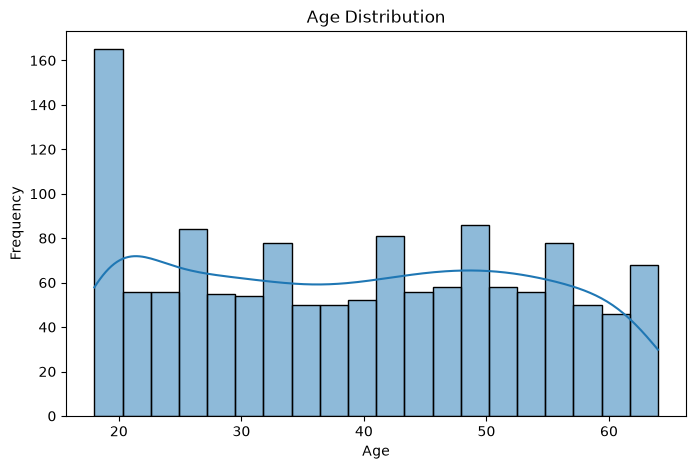

In [121]:
#Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## The population is fairly distributed across different age groups with a slight concentration among younger adults.

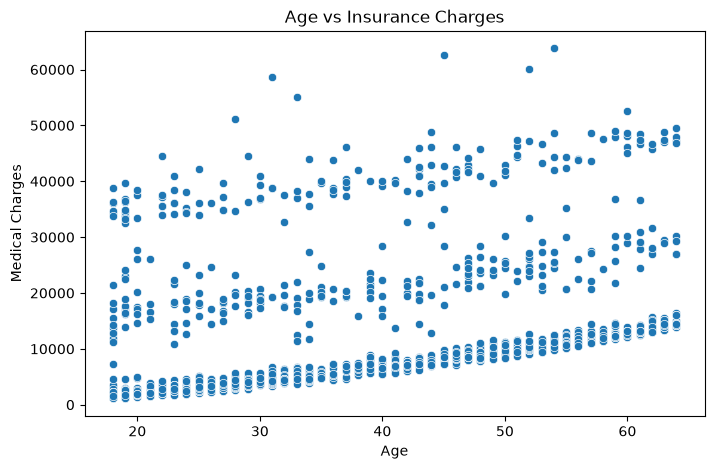

In [122]:
#Age vs Insurance Charges

plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.show()

### Interpretation
-	The dataset contains individuals between ages 18 and 64. 
-	Most policyholders are concentrated between 20 and 50 years. 
-	Medical insurance charges generally increase with age. 
-	Older individuals tend to incur higher healthcare costs than younger individuals. 

### Key Finding
Age has a positive relationship with insurance charges, indicating that healthcare expenses increase as people grow older.


## 4. BMI Analysis Visualization

### Objective
To determine the effect of Body Mass Index (BMI) on insurance charges.


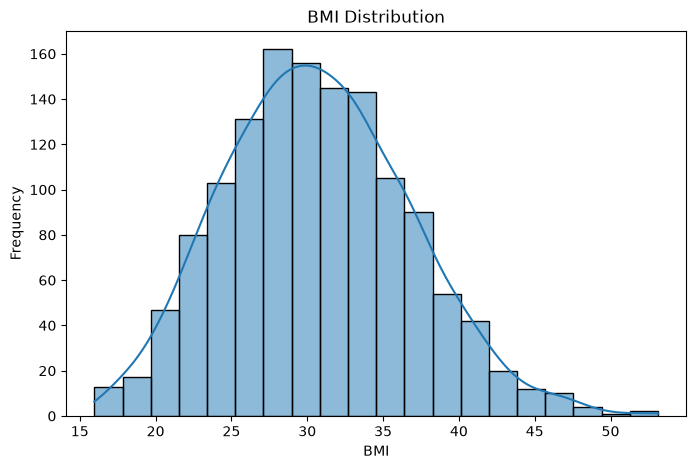

In [123]:
#BMI Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

Most policyholders have BMI levels indicating overweight conditions.

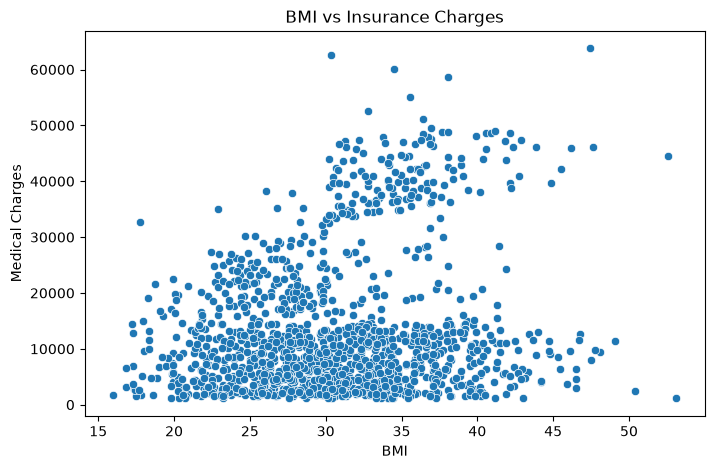

In [124]:
#BMI vs Charges

plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.show()

### Interpretation
-	BMI values are approximately normally distributed. 
-	Most individuals have BMI values between 25 and 35. 
-	Insurance charges tend to increase as BMI increases. 
-	Individuals with BMI above 30 generally have higher medical expenses. 

### Key Finding
BMI shows a positive correlation with insurance charges, suggesting that obesity-related health risks contribute to increased healthcare costs.


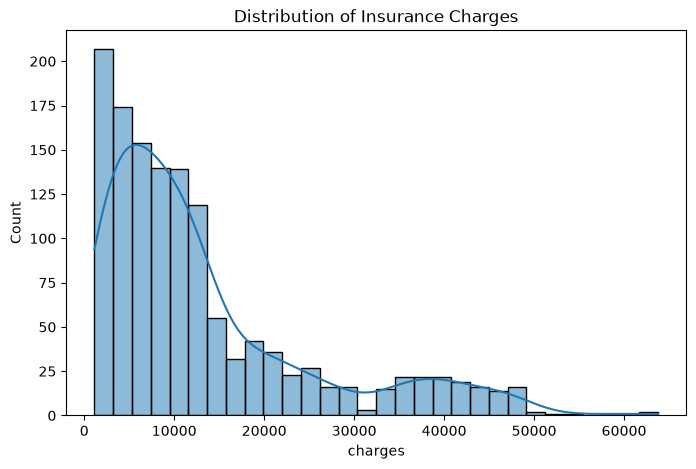

In [125]:
#Charges Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

The target variable is right-skewed, indicating a few individuals incur extremely high medical costs


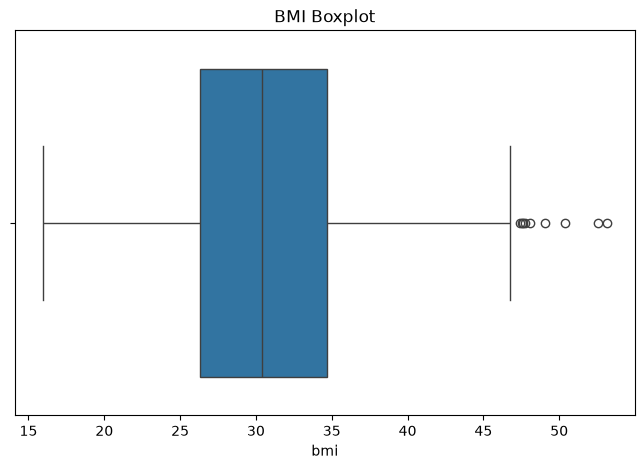

In [126]:
#Boxplot of BMI

plt.figure(figsize=(8,5))
sns.boxplot(x=df['bmi'])
plt.title('BMI Boxplot')
plt.show()

A few BMI outliers exist, representing individuals with exceptionally high body mass index values.

## 5. EDA Insights

### Summary of Findings
### Age
-	Age is positively correlated with medical insurance charges. 
-	Older individuals generally pay higher insurance costs. 
-	Healthcare expenses increase progressively with age. 
### BMI
-	BMI is positively associated with insurance charges. 
-	Individuals with higher BMI values tend to incur larger medical expenses. 
-	Obesity appears to be an important factor affecting healthcare costs. 
### Distribution of Charges
-	Insurance charges are highly skewed. 
-	A small number of policyholders generate very high medical costs. 
### Business Implications
i.	 Age significantly influences healthcare expenditure and should be retained as a key predictive feature.

ii.	 BMI contributes meaningfully to medical costs and should be included in predictive models.

iii. Insurance providers can use age and BMI information to better estimate future healthcare expenses.

iv.	 Preventive health programs targeting obesity may help reduce long-term medical costs.

## EDA for SEX, REGION, SMOKERS


The aim of this section is to understand the impact of sex, region and smoking on insurance charges


First we look at the distribution of each column using  the value_counts method to see how many rows fall into each category for sex, region and smoking status

In [127]:
# To see the  sex distribution
df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

 The result shows that both sexes are evenly distributed in the data

In [128]:
# To gain insight on the number of people in each region
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

The result shows there are more people in the south east, while the other three regions show even distribution

In [129]:
# To get the distribution of the smokers column

df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

The result shows there are for times more non smokers compared to smokers


#### Now that we have a feel of the distribution, we want to see how each of these categories influence insurance charges


In [130]:
# Groupby split each column by category, describe gives the statistical summary
df.groupby('sex')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
female,662.0,12569.578844,11128.703801,1607.5101,4885.158700,9412.9625,14454.691825,63770.42801
male,675.0,13974.998864,12971.958663,1121.8739,4654.022675,9377.9047,19006.685500,62592.87309


The result shows similar average cost between both genders


In [131]:
df.groupby('region')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,324.0,13406.384516,11255.803066,1694.7964,5194.322288,10057.652025,16687.364100,58571.07448
northwest,324.0,12450.840844,11073.125699,1621.3402,4733.635288,8976.977250,14788.747863,60021.39897
southeast,364.0,14735.411438,13971.098589,1121.8739,4440.886200,9294.131950,19526.286900,63770.42801
southwest,325.0,12346.937377,11557.179101,1241.5650,4751.070000,8798.593000,13462.520000,52590.82939


This shows the Eastern part of the country have a higher average cost, however NorthEast has a higher average and median charges but southeast has the highest recorded charge.

In [132]:
df.groupby("smoker")["charges"].describe()

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,1063.0,8440.660307,5992.973800,1121.8739,3988.883500,7345.72660,11363.019100,36910.60803
yes,274.0,32050.231832,11541.547176,12829.4551,20826.244213,34456.34845,41019.207275,63770.42801


Clearly smokers incur more charges which is shown across all metrics, the mean and median shows more than 4x higher charges for smokes compared to non smokers, however the max charge across both category is less than 2x. To investigate this further we use a boxplot 



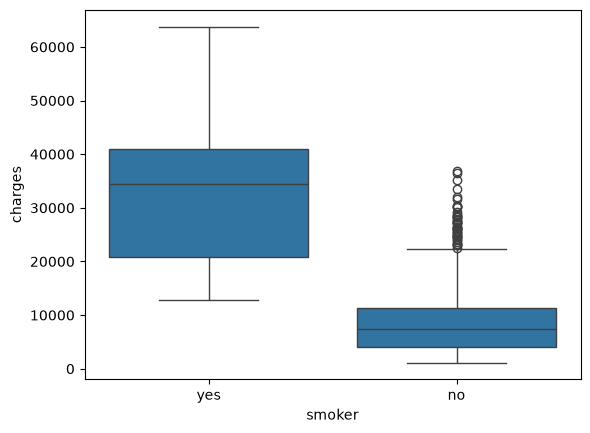

In [133]:
sns.boxplot(data= df, x = "smoker", y = "charges")
plt.show()

The box-plot shows there are outliers for non smokers which indicate that although smoking influences charges, there are other factors that contribute to higher charges for non smokers

In [134]:
# Does smoking effect differ by sex

df.groupby(['sex', 'smoker'])['charges'].describe()

count          mean           std         min           25%  \
sex    smoker                                                                
female no      547.0   8762.297300   6060.775970   1607.5101   4265.599100   
       yes     115.0  30678.996276  11907.536381  13844.5060  19696.432100   
male   no      516.0   8099.700161   5907.000174   1121.8739   3684.907500   
       yes     159.0  33042.005975  11202.670862  12829.4551  21241.526875   

                        50%          75%          max  
sex    smoker                                          
female no       7639.417450  11786.16660  36910.60803  
       yes     28950.469200  40918.31450  63770.42801  
male   no       6986.101975  10960.85900  32108.66282  
       yes     36085.219000  41797.58905  62592.87309

This shows that female non smokers have slightly higher charges compared to male non smokers

In [135]:
df.groupby(['region', 'smoker'])['charges'].describe()

count          mean           std         min           25%  \
region    smoker                                                                
northeast no      257.0   9165.531672   6157.196439   1694.7964   4438.263400   
          yes      67.0  29673.536473  11589.559770  12829.4551  19881.400425   
northwest no      266.0   8582.467101   6125.331366   1621.3402   4201.807987   
          yes      58.0  30192.003182  11413.827702  14711.7438  20834.130337   
southeast no      273.0   8032.216309   6137.329758   1121.8739   3471.409600   
          yes      91.0  34844.996824  11324.766536  16577.7795  23155.105450   
southwest no      267.0   8019.284513   5489.514421   1241.5650   3947.026500   
          yes      58.0  32269.063494  11270.279593  13844.5060  20396.042022   

                           50%           75%          max  
region    smoker                                           
northeast no       8342.908750  11938.255950  32108.66282  
          yes     28101.333050  39576.950850  58571.07448  
northwest no       7259.232050  11355.802575  33471.97189  
          yes     27488.996475  39918.948975  60021.39897  
southeast no       6652.528800  10982.501300  36580.28216  
          yes     37484.449300  43391.859400  63770.42801  
southwest no       7348.142000  11017.990500  36910.60803  
          yes     35165.256500  39809.292750  52590.82939

## Summary of Findings: Sex, Region, and Smoking Analysis

**Group sizes**
- Sex is roughly balanced (676 male, 662 female).
- Region is evenly split across four groups (~324–364 each).
- Smoker status is imbalanced: only 274 of 1,338 people (~20%) are smokers.

**Main effects**
- **Smoking is the dominant driver of charges.** Smokers pay a median of 
  ~34,000 vs ~8,000 for non-smokers — a gap of roughly 4x, with almost no 
  overlap between the two boxplot distributions.
- **Sex has almost no effect on its own.** Male and female non-smokers pay 
  nearly identical average charges (~8,100 vs ~8,762).
- **Region has almost no effect on its own.** Non-smoker charges are flat 
  across all four regions (~8,000–9,200).

**Interaction effects (where it gets interesting)**
- Sex and region barely matter *until* you condition on smoking status — 
  then differences appear:
  - Among smokers, males pay more on average than females (~33,042 vs 
    ~30,679).
  - Among smokers, southeast stands out with the highest average charges 
    (~34,845), noticeably above the other three regions (~29,700–32,300). 
    Southeast also has the most smokers (91 vs 58–67 elsewhere).

**Takeaway**
- Smoking status alone explains most of the variation in charges.
- Sex and region are weak predictors on their own, but they modestly amplify 
  or dampen the smoking effect within the smoker subgroup suggesting any 
  predictive model should include a smoker interaction term rather than 
  treating these as independent, additive effects.